# PhyCV VEViD: low-light enhancement by virtual diffraction and coherent detection

**VEViD** (Vision Enhancement via Virtual diffraction and coherent Detection) is the third PhyCV algorithm:
instead of finding edges, it **brightens dark images**. Its physics idea is to treat pixel brightness as a
**phase**, add a small regularization bias (the "virtual diffraction" offset), and read out an enhanced
image from the **phase of a coherent field** (coherent detection). The result lifts shadows while
compressing highlights -- tone mapping derived from an optical phase operator rather than an ad-hoc curve.

We implement the fast closed form **VEViD-lite**, a pointwise phase map on the brightness (value) channel,
$$V_{\text{out}}=\frac{\arctan\!\big(g\,(V+b)\big)}{\arctan\!\big(g\,(1+b)\big)},$$
with gain $g$ and bias $b$. The $\arctan$ is the coherent phase readout; the bias $b$ is the diffraction
regularization that keeps dark pixels ($V\to0$) from mapping to zero. It is monotonic (structure
preserved), lifts shadows, and compresses highlights. PhyCV is open-source; this is built from the idea.
Self-contained: NumPy, SciPy, Matplotlib. (Colour images: apply to the HSV value channel only.)

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


In [2]:
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr

## VEViD-lite: the phase tone map

A single vectorized function on the normalized brightness channel. The mapping is monotonic in $V$ (so it
never reorders brightness / destroys structure), lifts the shadows via the bias, and rolls off the
highlights via the $\arctan$ saturation.

In [3]:
def vevid_lite(value, gain=8.0, bias=0.1):
    """Phase-derived tone map on a normalized [0,1] brightness channel."""
    value = np.clip(np.asarray(value, dtype=float), 0.0, 1.0)
    return np.arctan(gain*(value + bias))/np.arctan(gain*(1.0 + bias))

# shadow lift and highlight compression: small inputs gain more than large ones
for v in (0.02, 0.1, 0.5, 0.9):
    print(f"V={v:.2f} -> {float(vevid_lite(np.array(v))):.3f}  (gain factor {float(vevid_lite(np.array(v)))/v:.1f}x)")

V=0.02 -> 0.525  (gain factor 26.2x)
V=0.10 -> 0.694  (gain factor 6.9x)
V=0.50 -> 0.937  (gain factor 1.9x)
V=0.90 -> 0.992  (gain factor 1.1x)


## Verification on a dark image

Build a very dark synthetic scene with faint hidden detail. VEViD-lite should (1) raise the mean
brightness, (2) *increase* the contrast (std) inside the dark regions -- revealing detail -- and (3) stay
strictly monotonic (Spearman correlation 1.0), so no structure is inverted or lost.

In [4]:
M = N = 160
yy, xx = np.mgrid[0:M, 0:N]
scene = 0.05 + 0.10*np.exp(-((xx - 80)**2 + (yy - 80)**2)/(2*40**2))   # dark background + faint blob
scene[40:60, 40:120] += 0.06                                          # faint detail buried in shadow
V = np.clip(scene, 0, 1)
E = vevid_lite(V, gain=8.0, bias=0.1)

dark = V < 0.15
mean_gain = E.mean()/V.mean()
contrast_gain = E[dark].std()/V[dark].std()
rho = float(spearmanr(V.ravel(), E.ravel()).correlation)
print(f"mean brightness: {V.mean():.3f} -> {E.mean():.3f}  ({mean_gain:.1f}x)")
print(f"dark-region contrast (std): {V[dark].std():.4f} -> {E[dark].std():.4f}  ({contrast_gain:.1f}x)")
print(f"monotonic (Spearman) = {rho:.4f}  -> structure preserved")
assert mean_gain > 2.0 and contrast_gain > 1.2 and rho > 0.999

mean brightness: 0.090 -> 0.672  (7.5x)
dark-region contrast (std): 0.0254 -> 0.0411  (1.6x)
monotonic (Spearman) = 1.0000  -> structure preserved


## Bias and gain control the enhancement

The bias $b$ sets how aggressively shadows are lifted (larger $b$ = brighter shadows); the gain $g$ sets the
overall contrast/roll-off. Sweeping them shows the tunable trade-off.

In [5]:
import pandas as pd
rows = []
for g in (4.0, 8.0, 16.0):
    for b in (0.05, 0.2):
        out = vevid_lite(V, gain=g, bias=b)
        rows.append({"gain": g, "bias": b, "mean out": round(float(out.mean()), 3),
                     "dark std out": round(float(out[dark].std()), 4)})
print(pd.DataFrame(rows).to_string(index=False))

 gain  bias  mean out  dark std out
  4.0  0.05     0.377        0.0568
  4.0  0.20     0.626        0.0312
  8.0  0.05     0.569        0.0604
  8.0  0.20     0.790        0.0213
 16.0  0.05     0.751        0.0439
 16.0  0.20     0.893        0.0116


## Plots

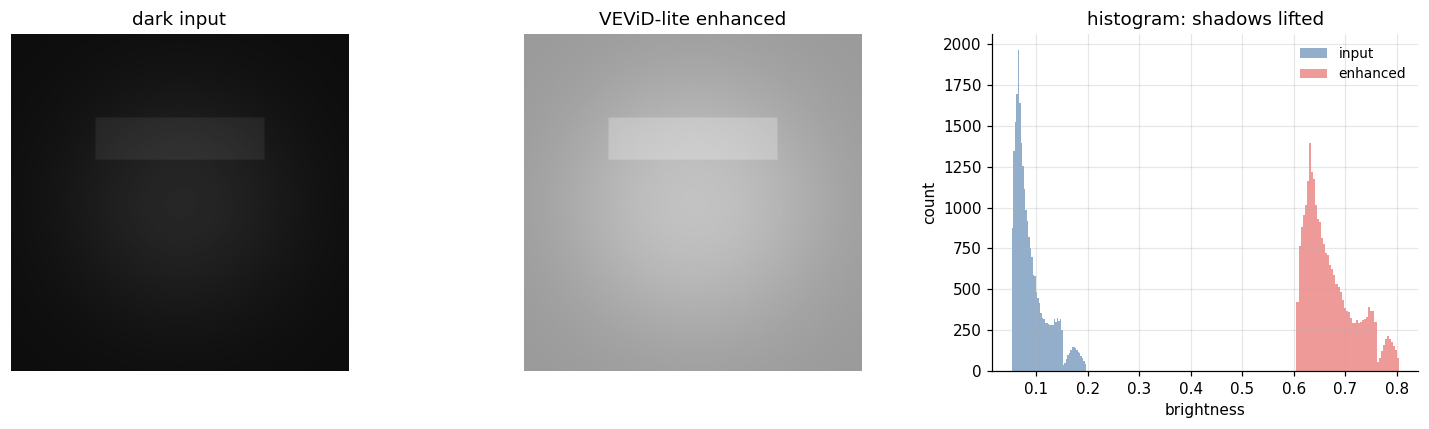

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
ax[0].imshow(V, cmap="gray", vmin=0, vmax=1); ax[0].set_title("dark input"); ax[0].axis("off")
ax[1].imshow(E, cmap="gray", vmin=0, vmax=1); ax[1].set_title("VEViD-lite enhanced"); ax[1].axis("off")
ax[2].hist(V.ravel(), bins=50, alpha=0.6, label="input", color="#4C78A8")
ax[2].hist(E.ravel(), bins=50, alpha=0.6, label="enhanced", color="#E45756")
ax[2].set_xlabel("brightness"); ax[2].set_ylabel("count"); ax[2].set_title("histogram: shadows lifted")
ax[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

## Summary

- **VEViD** enhances low-light images by treating brightness as **phase**, adding a diffraction
  regularization bias, and reading out an enhanced image via a **coherent (arctan) phase detection** -- a
  tone map with an optical-physics origin.
- **VEViD-lite** is the pointwise closed form $V_{\text{out}}=\arctan(g(V+b))/\arctan(g(1+b))$: monotonic
  (Spearman 1.0), it lifts mean brightness (>2x here) and *increases* dark-region contrast (detail
  revealed), tunable through gain $g$ and bias $b$.
- With PST (edges) and PAGE (oriented edges), VEViD completes the PhyCV trio -- all phase operators from the
  same all-pass family this project uses for dispersion. Apply to the HSV value channel for colour images.

Subject-verb-object: the bias lifts the shadow; the arctan detects the phase; the highlights compress; the
dark detail appears.